In [15]:
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [16]:
load_dotenv()

True

In [17]:
# models
MODEL_LARGE= "gemini-embedding-2"
MODEL_SMALL= "gemini-embedding-001"

In [18]:
# create the embedder

embedder_large= GoogleGenerativeAIEmbeddings(
    model= MODEL_LARGE
)

embedder_small= GoogleGenerativeAIEmbeddings(
    model= MODEL_SMALL
)

## **A. Sending Query**

In [19]:
query= "What is Openclaw/Moltbot and what are the major security concerns regarding this tool"

embeddings_large= embedder_large.embed_query(
    text= query
)

embeddings_small= embedder_small.embed_query(
    text= query
)

In [20]:
print(len(embeddings_large), "\n", len(embeddings_small))

3072 
 3072


#### Length of all mangnitudes in these embeddings equals 1 (Normalized Vector Embeddings)

In [21]:
embeddings_large[0:10]

[0.035330165,
 0.021894101,
 0.016750379,
 -0.0011040873,
 0.013283757,
 -0.01462442,
 -0.013765533,
 0.005711903,
 0.012595898,
 -0.034662735]

In [22]:
sum(embeddings_small)

-0.3799373912585

## **B. Sending Entire Document**

In [23]:
loader= PyPDFLoader(file_path= ".\Openclaw_Research_Report.pdf")
documents= loader.load()

len(documents)

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\patil\AppData\Local\Temp\ipykernel_21108\1579064034.py:1: SyntaxWarning: invalid escape sequence '\O'
  loader= PyPDFLoader(file_path= ".\Openclaw_Research_Report.pdf")


34

In [24]:
chunker= RecursiveCharacterTextSplitter(   
    chunk_size= 1000,
    chunk_overlap= 100
)

docs= chunker.split_documents(documents)     # list[docs]

print(docs)
len(docs)

[Document(metadata={'producer': 'Skia/PDF m127', 'creator': 'Chromium', 'creationdate': '2026-01-31T03:22:31+00:00', 'moddate': '2026-01-31T03:22:31+00:00', 'source': '.\\Openclaw_Research_Report.pdf', 'total_pages': 34, 'page': 0, 'page_label': '1'}, page_content='Report Date: January 31, 2026\nPrepared for: Technical Review and Strategic Assessment\nReport Version: 1.0\nMoltbot (formerly Clawdbot) represents one of the most viral open-source AI projects in\nGitHub history, achieving over 103,000 stars within three months of launch[32]. This self-\nhosted, agentic AI assistant has captured signi\x00cant developer attention by o\x00ering\nproactive automation, multi-channel messaging integration, and local-\x00rst architecture.\nHowever, this explosive growth has been accompanied by substantial security concerns,\ntrademark disputes, and deployment complexities that warrant careful evaluation.\nThis report provides comprehensive analysis across eleven key dimensions: naming\nhistory, c

87

#### 1 chunk embedding process= 1 API Call

In [25]:
# The "embed_documents" function requires a list[str] so we convert the documents (which came from .split_documents) into list[str]

text_documents = [ doc.page_content for doc in docs ]

document_embeddings=  embedder_large.embed_documents(
    texts= text_documents
)

In [26]:
len(document_embeddings)

87

In [27]:
len(document_embeddings[0])

3072

### So, 87 CHUNKS => 3072 EMBEDDINGS PER CHUNK
### embed_query()=> 1D list, embed_documents=> 2D list

In [28]:
document_embeddings[0]       

[0.004823693,
 0.03389108,
 -0.010144764,
 0.0032759844,
 -0.010674858,
 -0.008346257,
 -0.019065196,
 0.016420392,
 0.0048612445,
 -0.04566705,
 -0.013260955,
 -0.010229483,
 0.006880919,
 -0.020866385,
 -0.007531112,
 -0.012868916,
 0.049843855,
 -0.008142328,
 -0.0063492754,
 -0.0025272295,
 -0.008822409,
 0.00018929133,
 0.0127496375,
 0.025187815,
 -0.018028736,
 0.018074721,
 -0.008118627,
 -0.01568279,
 -0.018390523,
 0.12206062,
 -0.0014902946,
 -0.028396405,
 0.0013456778,
 0.004969576,
 0.0074661183,
 -0.004300352,
 0.0072789006,
 0.017538998,
 0.014260383,
 0.002541878,
 0.01711811,
 0.013207341,
 0.020037182,
 0.015666252,
 0.014996687,
 0.010769333,
 -0.0057677864,
 -0.00479471,
 0.0030580063,
 0.0049574184,
 -0.007537663,
 -0.0042589167,
 0.030918742,
 0.008426018,
 0.0004550446,
 0.008553537,
 0.032831155,
 9.7801516e-05,
 0.005707361,
 0.0016571684,
 -0.004701186,
 -0.0038529462,
 0.029697001,
 0.022051886,
 0.0071428665,
 -0.022186222,
 0.013603276,
 -0.017103933,
 0.0

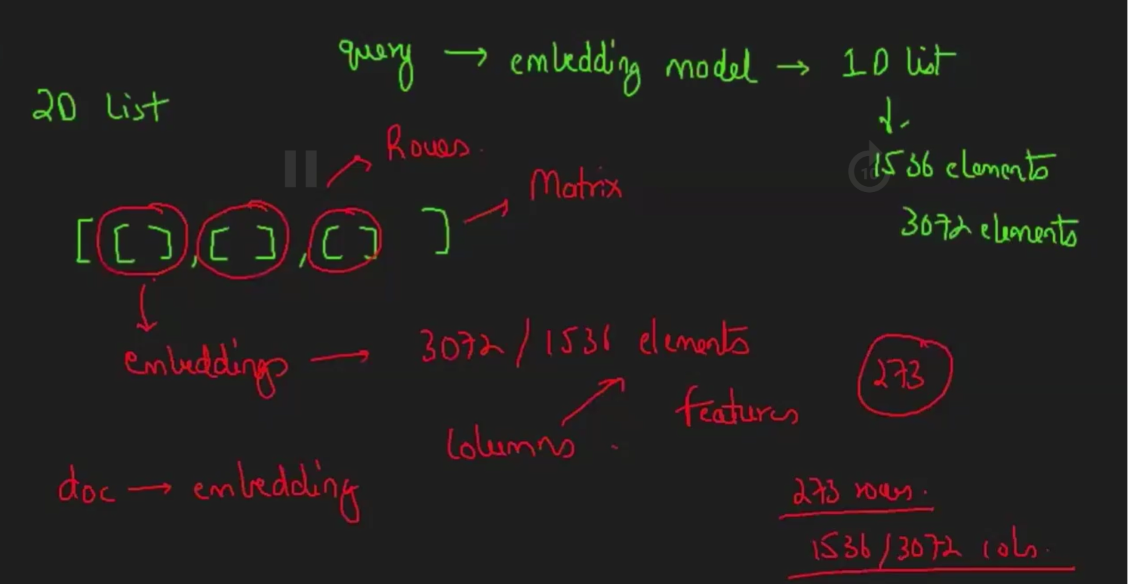

### **Custom Dimensions Query**

In [37]:
embedder_large_custom_dim= GoogleGenerativeAIEmbeddings(
    model= MODEL_LARGE,
    output_dimensionality= 256
)

In [38]:
query_embeddings= embedder_large_custom_dim.embed_query(
    text= query
)
len(query_embeddings)

256

In [ ]:
# 1D List
(query_embeddings)

[0.111035265,
 0.06880854,
 0.052642908,
 -0.0034699137,
 0.041748047,
 -0.04596147,
 -0.04326217,
 0.017951306,
 0.03958625,
 -0.108937666,
 -0.029064631,
 -0.025029203,
 -0.00916014,
 -0.008035739,
 -0.006322867,
 0.06868894,
 0.13136186,
 -0.02000501,
 -0.009540833,
 -0.056097653,
 -0.026310321,
 -0.050929695,
 0.015845858,
 -0.016770788,
 -0.064725175,
 0.013924712,
 -0.06363412,
 -0.0007759958,
 -0.01936281,
 0.2962131,
 -0.038368534,
 -0.09839855,
 -0.0077561475,
 -0.041663785,
 0.049172074,
 -0.026399596,
 -0.0076685343,
 -0.0038287432,
 0.038953975,
 -0.021859573,
 0.008396916,
 -0.005862949,
 -0.018191624,
 0.06993782,
 0.08025514,
 -0.0550974,
 0.0038721766,
 -0.0946564,
 0.015885437,
 0.008116838,
 -0.008140948,
 0.028656587,
 0.044113353,
 0.053869132,
 0.021560429,
 -0.021776585,
 0.06516137,
 0.033464387,
 0.04729833,
 0.09365987,
 0.017982818,
 -0.0033583546,
 0.028905524,
 0.1060932,
 -0.041898083,
 -0.08736732,
 -0.009956265,
 -0.031965308,
 0.09028526,
 0.07702095,
 0

In [40]:
query_embeddings[0:20]

[0.111035265,
 0.06880854,
 0.052642908,
 -0.0034699137,
 0.041748047,
 -0.04596147,
 -0.04326217,
 0.017951306,
 0.03958625,
 -0.108937666,
 -0.029064631,
 -0.025029203,
 -0.00916014,
 -0.008035739,
 -0.006322867,
 0.06868894,
 0.13136186,
 -0.02000501,
 -0.009540833,
 -0.056097653]